Here we replicate the phase diagram from 'Provably efficient machine learning for quantum many-body problems' Huang et al (which in turn is based on 'Probing many-body dynamics on a 51-atom quantum simulator' by Bernien et al.).

One of the models studied has Hamiltonian
$$ H = \frac{\Omega}{2}\sum_i X_i - \Delta \sum_i N_i + \Omega \sum_{i<j} \left(\frac{R_b}{a|i-j|} \right)^6 N_iN_j$$

We introduce dimensionless parameters
$$ x_1 = \Delta/\Omega$$
and
$$ x_2 = R_b/a$$

$$ H(x_1, x_2)/\Omega = \frac{1}{2}\sum_i X_i - x_1 \sum_i N_i + \sum_{i<j} \left(\frac{x_2}{|i-j|} \right)^6 N_iN_j$$


In [43]:
import qutip as qp
import numpy as np
import matplotlib.pyplot as plt

In [48]:
def gen_hamiltonian(n_qubits, x1, x2):
    hamiltonian = 0.

    number_op = 0.5 * (qp.qeye(2) - qp.sigmaz())

    for i in range(n_qubits):
        op = [qp.qeye(2)]*n_qubits
        op[i] = qp.sigmax()
        hamiltonian += 0.5 * qp.tensor(op)

    for i in range(n_qubits):
        op = [qp.qeye(2)]*n_qubits
        op[i] = number_op
        hamiltonian -= x1 * qp.tensor(op)

    for i in range(n_qubits-1):
        for j in range(i+1, n_qubits):
            op = [qp.qeye(2)]*n_qubits
            op[i] = number_op
            op[j] = number_op
            coef = (x2 / abs(i-j)) ** 6
            hamiltonian += coef * qp.tensor(op)

    return hamiltonian

In [55]:
n_qubits = 10
x1 = 4.0
x2 = 3.75

hamiltonian = gen_hamiltonian(n_qubits, x1, x2)

In [56]:
energy0, psi0 = hamiltonian.groundstate()

In [57]:
occ_exp = 0.

for i, amplitude in enumerate(psi0.full()):
    prob = np.real(np.conj(amplitude) * amplitude).item()
    state = np.binary_repr(i, n_qubits)
    #print(i, prob, state)
    occ_exp += np.array([float(c) for c in state]) * prob

occ_exp

array([9.71214840e-01, 7.01686439e-03, 3.66795815e-04, 1.57597357e-03,
       4.74398048e-01, 4.74398048e-01, 1.57597357e-03, 3.66795815e-04,
       7.01686439e-03, 9.71214840e-01])

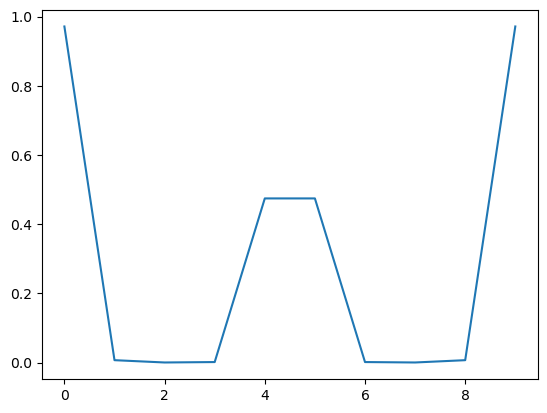

In [58]:
plt.plot(occ_exp)